<a href="https://colab.research.google.com/github/stratbuilds12/student-reading-risk-prediction/blob/main/student_year_3_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.Business Understanding

Aim :To develop and evaluate machine learning models that accurately predict a primary school student's risk of underperforming in the Year 3 NAPLAN Reading test, using Year 1-2 literacy, numeracy, demographic, family-background, and school-SES data, so that Data2Intel can recommend a reliable early-intervention screening tool.

Context : Primary schools track demographic, family-background, school-SES, and Year 1-2 literacy/numeracy assessment data for students who will sit the Year 3 NAPLAN Reading test.

Needs : Identify, before Year 3 NAPLAN, which students are likely at risk so literacy support can be targeted early.

Value Proposition: 	A predictive model lets schools intervene 1-2 years earlier than waiting for the Year 3 result, converting a lagging measure into a leading signal.

Stakeholders:	Andy Ng (Director, Data & Insights); Elena Race (Director, Education); school teachers/leadership; students & families.

Solution: 	Two supervised classifiers + one clustering model, trained on Year 1-2 assessment and background data.

Change : Shifts literacy support from reactive (after NAPLAN) to proactive (from Year 1/2 data) — requires stakeholders to trust a probabilistic risk score.




#2.Import Libraries and Data loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
url="/content/drive/MyDrive/MIS710  class discussion/LA4Schools_ReadingRisk_T2_2026.csv"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv(url)
TARGET = "Year3_Reading_At_Risk"
print("\nShape:", df.shape)


pandas: 2.2.3
numpy: 2.1.3
seaborn: 0.13.2
scikit-learn: 1.6.1

Shape: (2000, 34)


In [4]:
df.head()

,StudentID,TextLevel-01-SOY,TextLevel-01-MOY,TextLevel-01-EOY,TextLevel-02-SOY,TextLevel-02-MOY,TextLevel-02-EOY,WritingVocab-01-SOY,HRSIW-01-SOY,Counting-01,Counting-02,Place Value-01,Place Value-02,Addition and Subtraction-01,Addition and Subtraction-02,Multiplication and Division-01,Multiplication and Division-02,Kinder_Age,Gender,Disability_Non-disable,Disability_Cognitive,Disability_Physical,Disability_Sensory,Disability_SocialEmotional,NCCD-Funded,NumSibling,SiblingOrder,01.SES,02.SES,NumAbvYear9,NumAbvDiploma,NumProf,Year_02,Year3_Reading_At_Risk
0,793539920,20,24,31,32,29,29,36,37,5,5,3,3,4,5,2,4,5.498630,Male,1,0,0,0,0,0,2,2,95,95,2,1,1,2018,False
1,550065192,22,23,26,29,32,32,39,47,3,4,2,2,1,2,2,2,5.367123,Female,1,0,0,0,0,0,2,1,114,114,2,1,1,2020,False
2,181544661,26,30,29,28,31,31,47,48,1,4,1,2,3,3,2,2,6.073973,Female,1,0,0,0,0,0,2,2,109,109,2,2,2,2020,False
3,351553699,5,12,18,18,17,23,9,34,1,3,0,1,1,1,2,2,5.476712,Female,1,0,0,0,0,0,3,2,98,98,2,1,0,2017,True
4,458666003,5,8,21,25,21,27,21,22,1,3,0,2,1,0,0,2,5.087671,Female,1,0,0,0,0,0,2,1,93,93,2,1,1,2020,True


In [5]:
# Data dictionary check — quick column overview
df.dtypes.to_frame('dtype')


,dtype
StudentID,int64
TextLevel-01-SOY,int64
TextLevel-01-MOY,int64
TextLevel-01-EOY,int64
TextLevel-02-SOY,int64
TextLevel-02-MOY,int64
TextLevel-02-EOY,int64
WritingVocab-01-SOY,int64
HRSIW-01-SOY,int64
Counting-01,int64


#3.Data Quality Assesment

In [6]:
# Finding Missing and duplicate Values.
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None found.")

print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate StudentID:", df['StudentID'].duplicated().sum())


=== MISSING VALUES ===
None found.

=== DUPLICATES ===
Duplicate rows: 0
Duplicate StudentID: 0


In [7]:
print("=== OUT-OF-RANGE CHECKS ===")
textlevel_cols = [c for c in df.columns if c.startswith('TextLevel')]
for c in textlevel_cols:
    bad = df[(df[c] < 0) | (df[c] > 31)]
    if len(bad) > 0:
        print(f"{c}: {len(bad)} invalid values -> {sorted(bad[c].unique())}")

print("\nHRSIW-01-SOY negatives:", (df['HRSIW-01-SOY'] < 0).sum())

for c in ['NumAbvYear9', 'NumAbvDiploma', 'NumProf']:
    bad = df[df[c] > 2]
    if len(bad) > 0:
        print(f"{c}: {len(bad)} invalid rows -> {sorted(bad[c].unique())}")


=== OUT-OF-RANGE CHECKS ===
TextLevel-01-SOY: 14 invalid values -> [np.int64(-4), np.int64(-3), np.int64(-1), np.int64(32), np.int64(33), np.int64(34)]
TextLevel-01-MOY: 11 invalid values -> [np.int64(32), np.int64(33)]
TextLevel-01-EOY: 13 invalid values -> [np.int64(32), np.int64(33), np.int64(34)]
TextLevel-02-SOY: 37 invalid values -> [np.int64(32), np.int64(33), np.int64(34), np.int64(36)]
TextLevel-02-MOY: 36 invalid values -> [np.int64(32), np.int64(33), np.int64(34)]
TextLevel-02-EOY: 74 invalid values -> [np.int64(32), np.int64(33)]

HRSIW-01-SOY negatives: 6
NumAbvYear9: 1 invalid rows -> [np.int64(3)]


In [8]:
disab_cols = ['Disability_Non-disable','Disability_Cognitive','Disability_Physical',
              'Disability_Sensory','Disability_SocialEmotional']
print("Disability row-sums (should all equal 1):")
print(df[disab_cols].sum(axis=1).value_counts())


Disability row-sums (should all equal 1):
1    2000
Name: count, dtype: int64


In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
StudentID,2000.0,5.510786e+08,2.615616e+08,1.003399e+08,3.295180e+08,5.503851e+08,7.836270e+08,9.995696e+08
TextLevel-01-SOY,2000.0,1.069900e+01,6.100820e+00,-4.000000e+00,6.000000e+00,1.000000e+01,1.400000e+01,3.400000e+01
TextLevel-01-MOY,2000.0,1.500150e+01,5.489496e+00,0.000000e+00,1.100000e+01,1.400000e+01,1.800000e+01,3.300000e+01
TextLevel-01-EOY,2000.0,2.113000e+01,4.578600e+00,4.000000e+00,1.800000e+01,2.100000e+01,2.400000e+01,3.400000e+01
TextLevel-02-SOY,2000.0,2.178650e+01,5.220205e+00,2.000000e+00,1.800000e+01,2.200000e+01,2.500000e+01,3.600000e+01
TextLevel-02-MOY,2000.0,2.407300e+01,4.691340e+00,5.000000e+00,2.100000e+01,2.400000e+01,2.800000e+01,3.400000e+01
TextLevel-02-EOY,2000.0,2.699850e+01,3.765314e+00,5.000000e+00,2.500000e+01,2.800000e+01,3.000000e+01,3.300000e+01
WritingVocab-01-SOY,2000.0,2.201850e+01,1.267910e+01,0.000000e+00,1.300000e+01,2.000000e+01,2.900000e+01,9.500000e+01
HRSIW-01-SOY,2000.0,3.050800e+01,1.002069e+01,-3.000000e+00,2.500000e+01,3.200000e+01,3.700000e+01,5.800000e+01
Counting-01,2000.0,1.758000e+00,9.358814e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00


### 3.1 Cleaning decisions

| Issue | Rows affected | Fix | Justification |
|---|---|---|---|
| TextLevel out of 0-31 range | 17 | Clip to [0,31] | Small boundary errors; clipping preserves sample size (drop would lose real students) |
| HRSIW-01-SOY negative | 6 | Clip to >=0 | Same reasoning — likely data-entry sign error |
| NumAbvYear9 = 3 | 1 | Clip to 2 | Max possible is 2 parents; value is logically impossible |
| Missing values | 0 | None needed | Dataset is complete |
| Duplicates | 0 | None needed | Every StudentID is unique |


In [10]:
textlevel_cols = [c for c in df.columns if c.startswith('TextLevel')]
for c in textlevel_cols:
    df[c] = df[c].clip(lower=0, upper=31)
df['HRSIW-01-SOY'] = df['HRSIW-01-SOY'].clip(lower=0)
for c in ['NumAbvYear9', 'NumAbvDiploma', 'NumProf']:
    df[c] = df[c].clip(upper=2)

print("Cleaning verified:")
for c in textlevel_cols:
    print(f"  {c}: min={df[c].min()}, max={df[c].max()}")
print(f"  HRSIW-01-SOY: min={df['HRSIW-01-SOY'].min()}")
print(f"  NumAbvYear9: max={df['NumAbvYear9'].max()}")

Cleaning verified:
  TextLevel-01-SOY: min=0, max=31
  TextLevel-01-MOY: min=0, max=31
  TextLevel-01-EOY: min=4, max=31
  TextLevel-02-SOY: min=2, max=31
  TextLevel-02-MOY: min=5, max=31
  TextLevel-02-EOY: min=5, max=31
  HRSIW-01-SOY: min=0
  NumAbvYear9: max=2


# 4.Exploratory Data Analysis



## 4.1 Target distribution

Year3_Reading_At_Risk
False    1600
True      400
Name: count, dtype: int64
Year3_Reading_At_Risk
False    0.8
True     0.2
Name: proportion, dtype: float64


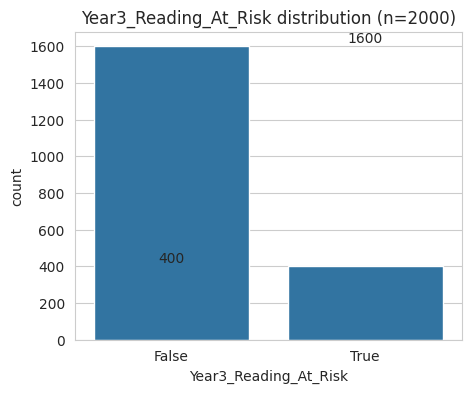

In [11]:
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(3))

plt.figure(figsize=(5,4))
sns.countplot(x=TARGET, data=df)
plt.title(f'Year3_Reading_At_Risk distribution (n={len(df)})')
for i, v in enumerate(df[TARGET].value_counts().sort_index(ascending=False)):
    plt.text(i, v+20, str(v), ha='center')
plt.show()


##  4.2 Year 1 Reading Skills Vs Risk

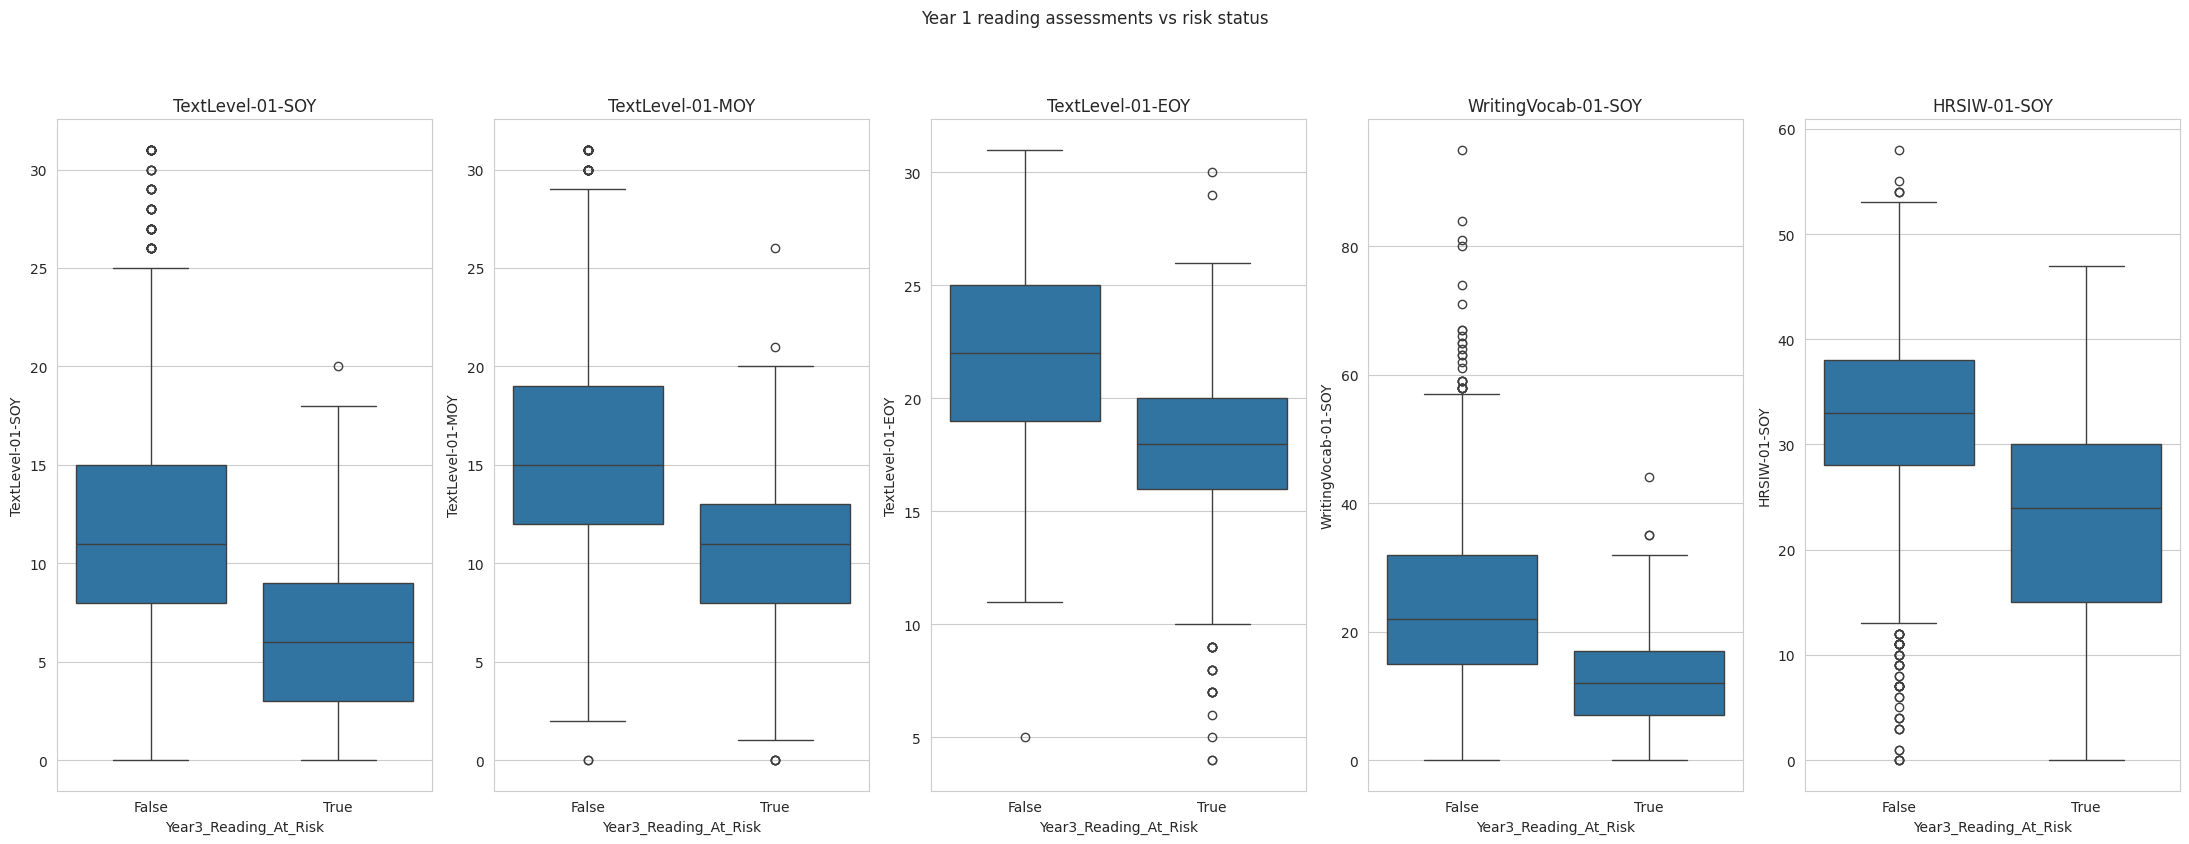

                      TextLevel-01-SOY        TextLevel-01-MOY        TextLevel-01-EOY        WritingVocab-01-SOY        HRSIW-01-SOY       
                                  mean median             mean median             mean median                mean median         mean median
Year3_Reading_At_Risk                                                                                                                       
False                            11.81   11.0            16.01   15.0            22.07   22.0               24.34   22.0        32.46   33.0
True                              6.28    6.0            10.92   11.0            17.34   18.0               12.72   12.0        22.74   24.0


In [12]:
y1_reading = ['TextLevel-01-SOY','TextLevel-01-MOY','TextLevel-01-EOY','WritingVocab-01-SOY','HRSIW-01-SOY']
fig, axes = plt.subplots(1, len(y1_reading), figsize=(22,8))
for ax, c in zip(axes, y1_reading):
    sns.boxplot(x=TARGET, y=c, data=df, ax=ax)
    ax.set_title(c)
plt.suptitle('Year 1 reading assessments vs risk status', y=1.05)
plt.tight_layout(); plt.show()

print(df.groupby(TARGET)[y1_reading].agg(['mean','median']).round(2))


## 4.3 Year1 - Year2 development trajectory

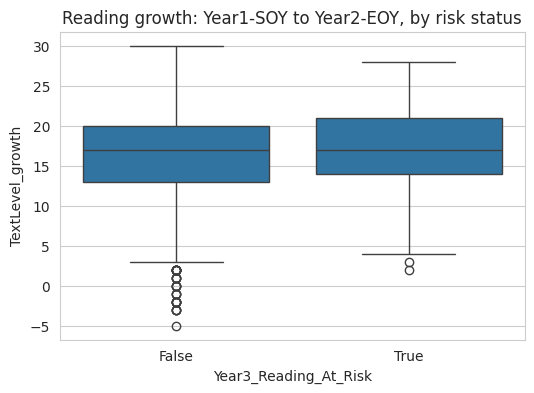

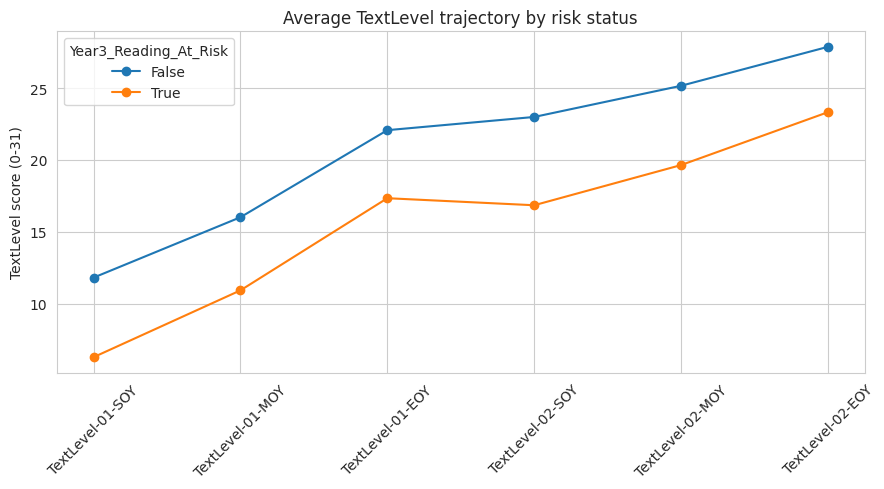

In [13]:
df['TextLevel_growth'] = df['TextLevel-02-EOY'] - df['TextLevel-01-SOY']

plt.figure(figsize=(6,4))
sns.boxplot(x=TARGET, y='TextLevel_growth', data=df)
plt.title('Reading growth: Year1-SOY to Year2-EOY, by risk status')
plt.show()

traj_cols = ['TextLevel-01-SOY','TextLevel-01-MOY','TextLevel-01-EOY',
             'TextLevel-02-SOY','TextLevel-02-MOY','TextLevel-02-EOY']
traj = df.groupby(TARGET)[traj_cols].mean().T
plt.figure(figsize=(9,5))
traj.plot(marker='o', ax=plt.gca())
plt.title('Average TextLevel trajectory by risk status')
plt.xticks(rotation=45)
plt.ylabel('TextLevel score (0-31)')
plt.legend(title=TARGET)
plt.tight_layout(); plt.show()


## 4.4 Numeracy vs risk

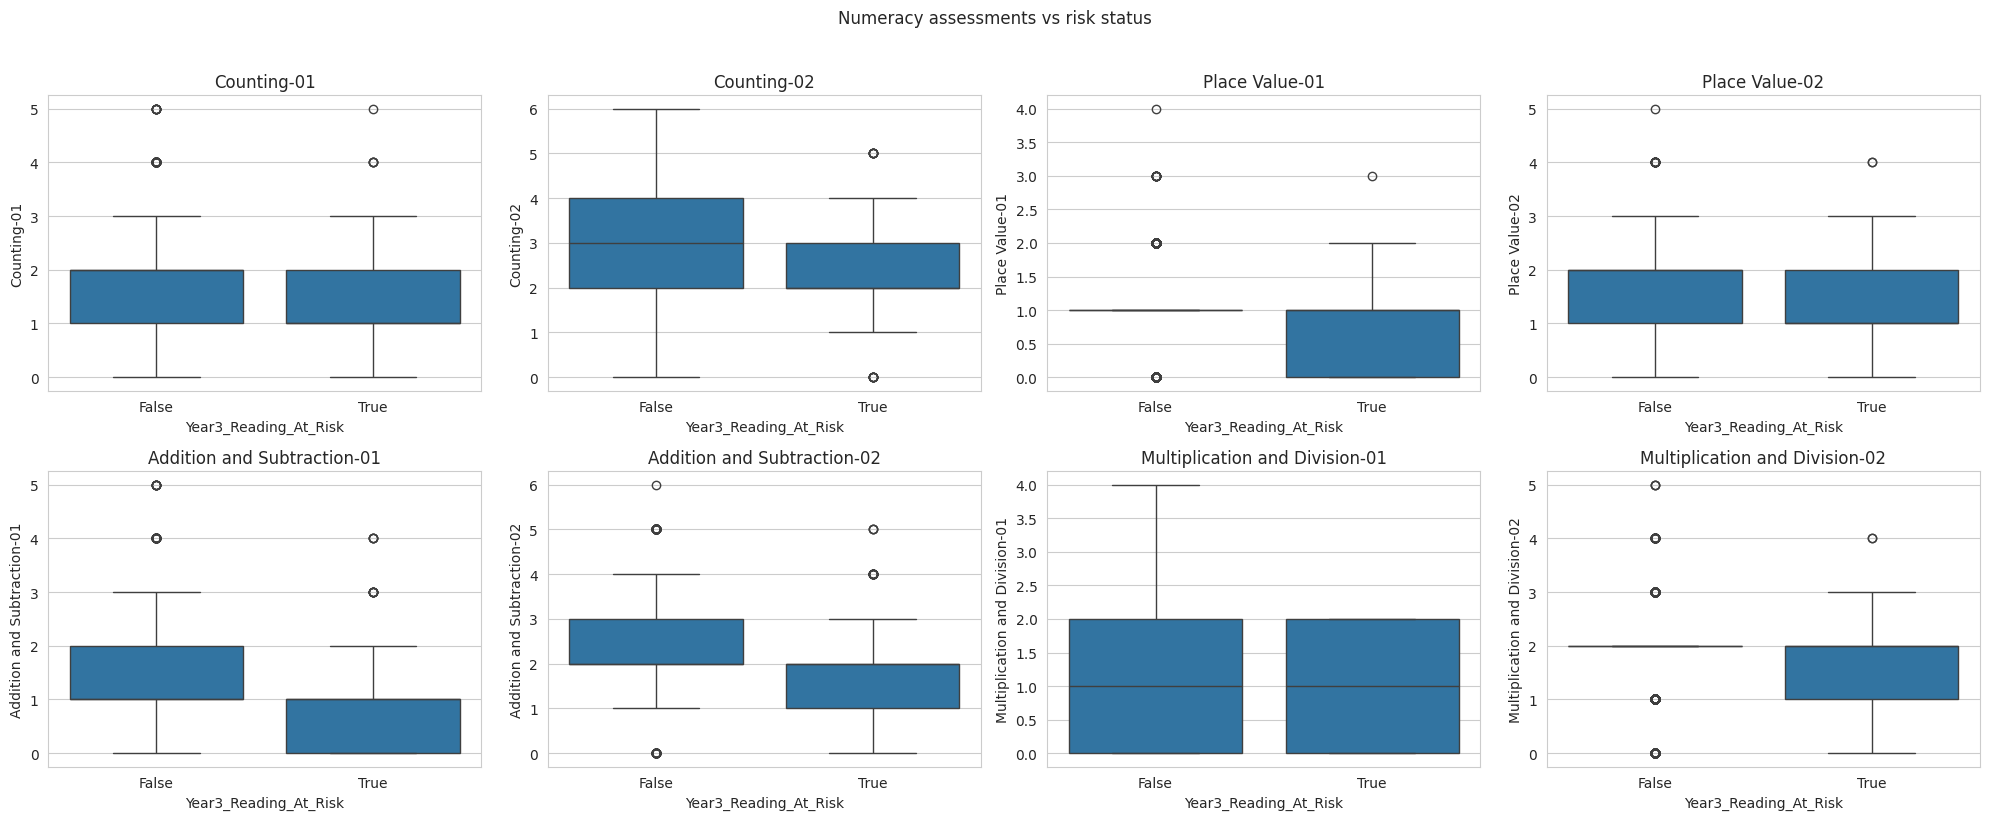

In [14]:
numeracy_cols = ['Counting-01','Counting-02','Place Value-01','Place Value-02',
                  'Addition and Subtraction-01','Addition and Subtraction-02',
                  'Multiplication and Division-01','Multiplication and Division-02']
fig, axes = plt.subplots(2,4, figsize=(20,8))
for ax, c in zip(axes.flatten(), numeracy_cols):
    sns.boxplot(x=TARGET, y=c, data=df, ax=ax)
    ax.set_title(c)
plt.suptitle('Numeracy assessments vs risk status', y=1.02)
plt.tight_layout(); plt.show()


## 4.5 Demographics — Gender, Kinder Age vs risk

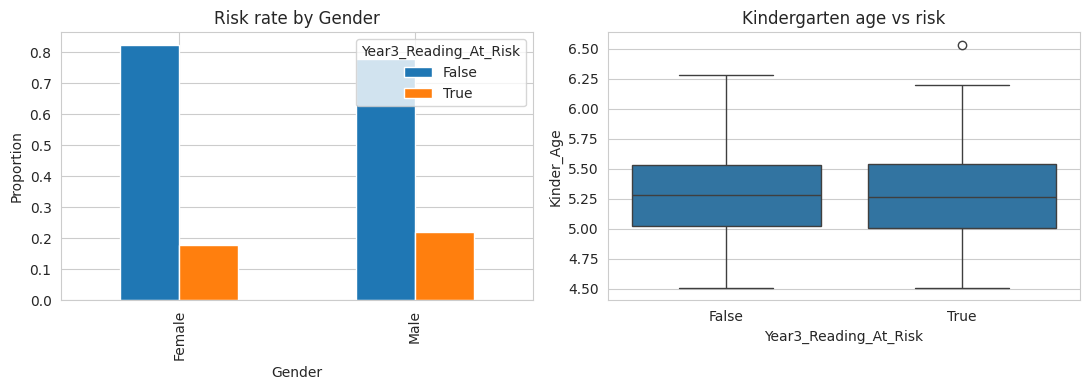

Year3_Reading_At_Risk  False  True 
Gender                             
Female                 0.823  0.177
Male                   0.778  0.222


In [15]:
fig, axes = plt.subplots(1,2, figsize=(11,4))

gender_risk = pd.crosstab(df['Gender'], df[TARGET], normalize='index')
gender_risk.plot(kind='bar', ax=axes[0])
axes[0].set_title('Risk rate by Gender')
axes[0].set_ylabel('Proportion')

sns.boxplot(x=TARGET, y='Kinder_Age', data=df, ax=axes[1])
axes[1].set_title('Kindergarten age vs risk')
plt.tight_layout(); plt.show()

print(pd.crosstab(df['Gender'], df[TARGET], normalize='index').round(3))


## 4.6 Disability & NCCD funding vs risk

Disability_Non-disable: risk rate = 13.54%  (n=1381)
Disability_Cognitive: risk rate = 38.38%  (n=469)
Disability_Physical: risk rate = 4.48%  (n=67)
Disability_Sensory: risk rate = 20.00%  (n=10)
Disability_SocialEmotional: risk rate = 38.36%  (n=73)

NCCD-Funded risk rate:
NCCD-Funded
0    0.184
1    0.360
Name: Year3_Reading_At_Risk, dtype: float64


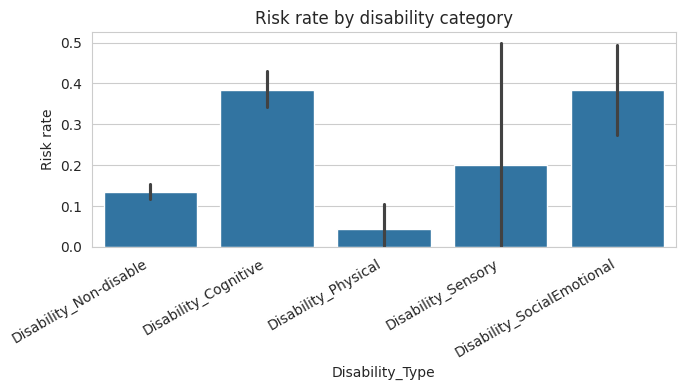

In [16]:
for c in disab_cols:
    rate = df.groupby(c)[TARGET].mean()
    print(f"{c}: risk rate = {rate.get(1, float('nan')):.2%}  (n={df[c].sum()})")

print("\nNCCD-Funded risk rate:")
print(df.groupby('NCCD-Funded')[TARGET].mean().round(3))

plt.figure(figsize=(7,4))
disab_summary = df[disab_cols + [TARGET]].melt(id_vars=TARGET, var_name='Disability_Type', value_name='Flag')
disab_summary = disab_summary[disab_summary['Flag']==1]
sns.barplot(x='Disability_Type', y=TARGET, data=disab_summary, estimator=lambda x: sum(x)/len(x))
plt.xticks(rotation=30, ha='right')
plt.ylabel('Risk rate')
plt.title('Risk rate by disability category')
plt.tight_layout(); plt.show()


## 4.7 School SES vs risk

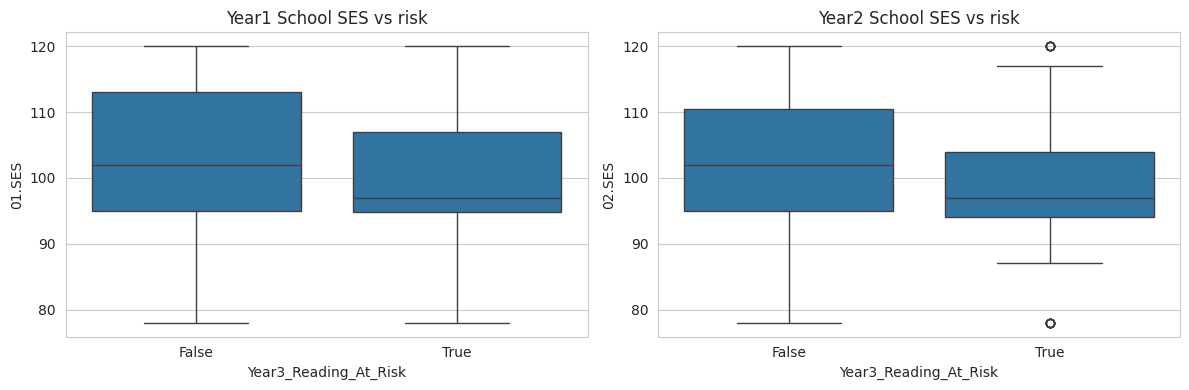

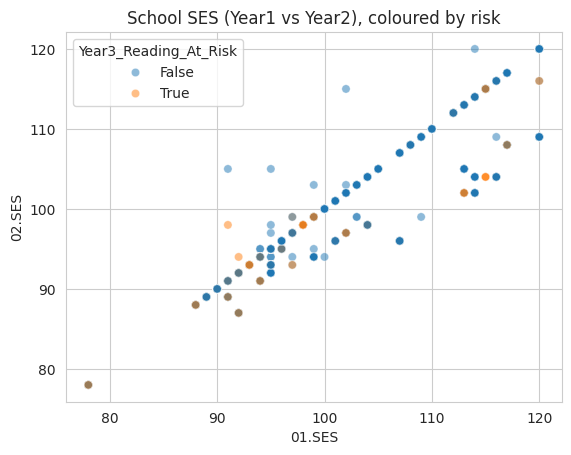

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(x=TARGET, y='01.SES', data=df, ax=axes[0]); axes[0].set_title('Year1 School SES vs risk')
sns.boxplot(x=TARGET, y='02.SES', data=df, ax=axes[1]); axes[1].set_title('Year2 School SES vs risk')
plt.tight_layout(); plt.show()

sns.scatterplot(x='01.SES', y='02.SES', hue=TARGET, data=df, alpha=0.5)
plt.title('School SES (Year1 vs Year2), coloured by risk')
plt.show()


## 4.8 Family background vs risk

                       NumSibling  SiblingOrder  NumAbvYear9  NumAbvDiploma  NumProf
Year3_Reading_At_Risk                                                               
False                        2.34          1.72         1.59           0.94     0.80
True                         2.43          1.84         1.48           0.69     0.62


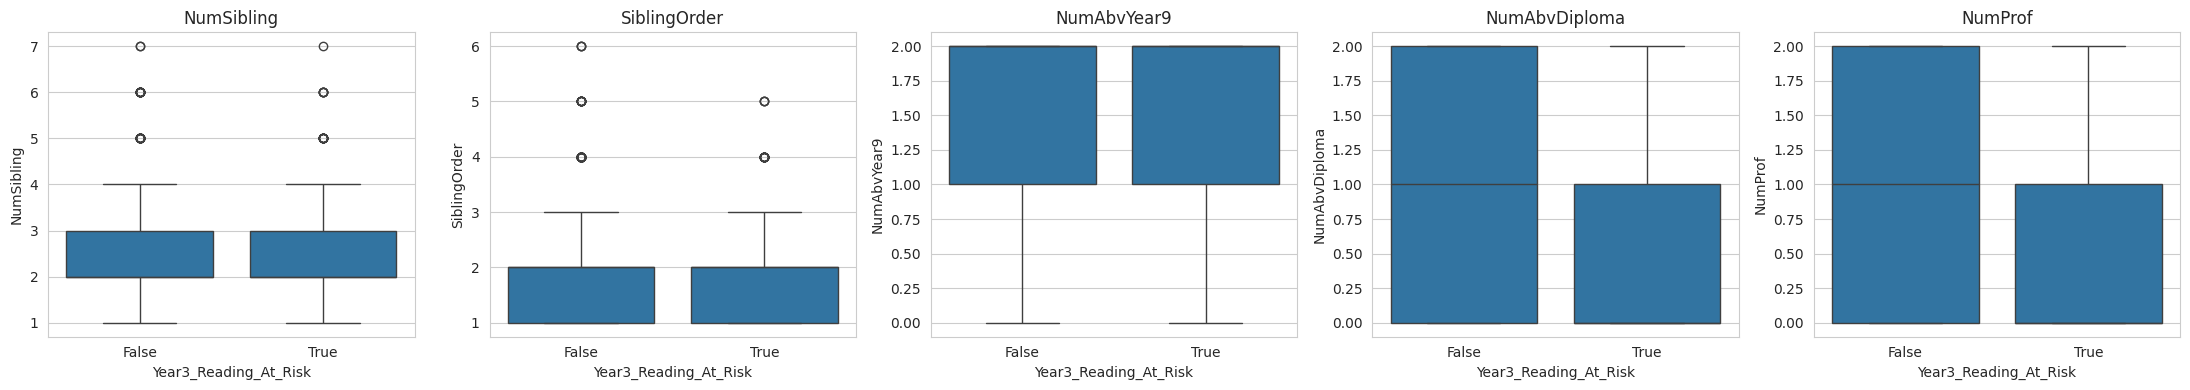

In [18]:
family_cols = ['NumSibling','SiblingOrder','NumAbvYear9','NumAbvDiploma','NumProf']
print(df.groupby(TARGET)[family_cols].mean().round(2))

fig, axes = plt.subplots(1, len(family_cols), figsize=(22,4))
for ax, c in zip(axes, family_cols):
    sns.boxplot(x=TARGET, y=c, data=df, ax=ax)
    ax.set_title(c)
plt.tight_layout(); plt.show()


## 4.9 Full correlation heatmap + ranked correlation with target

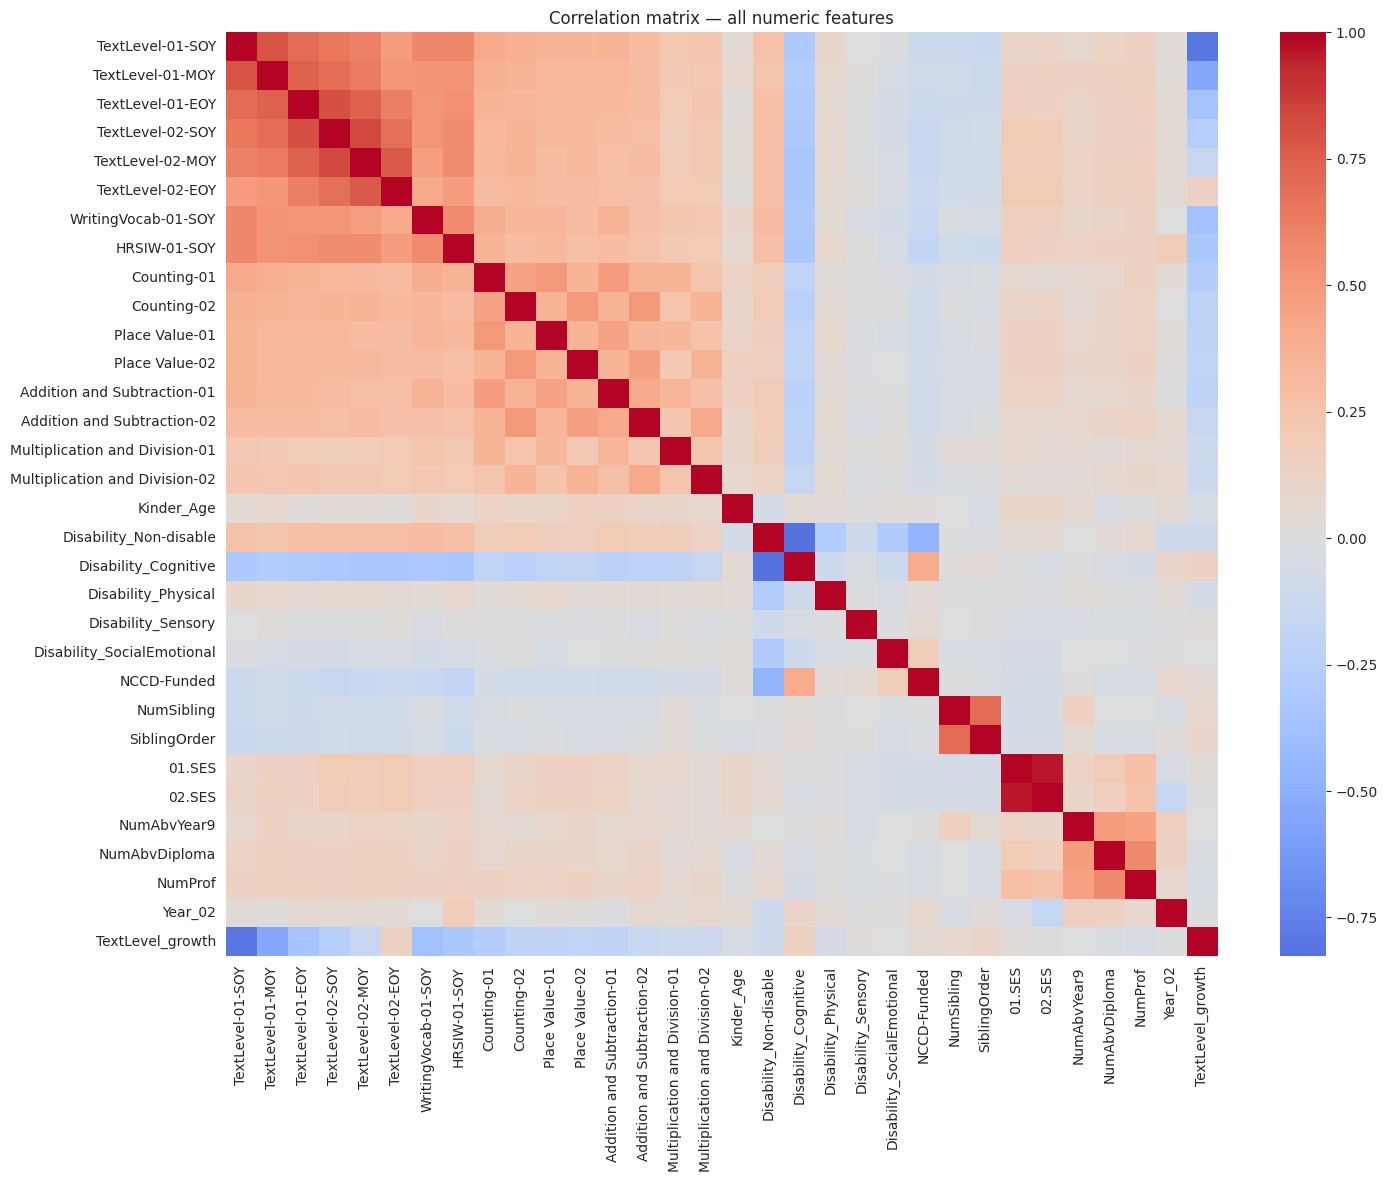

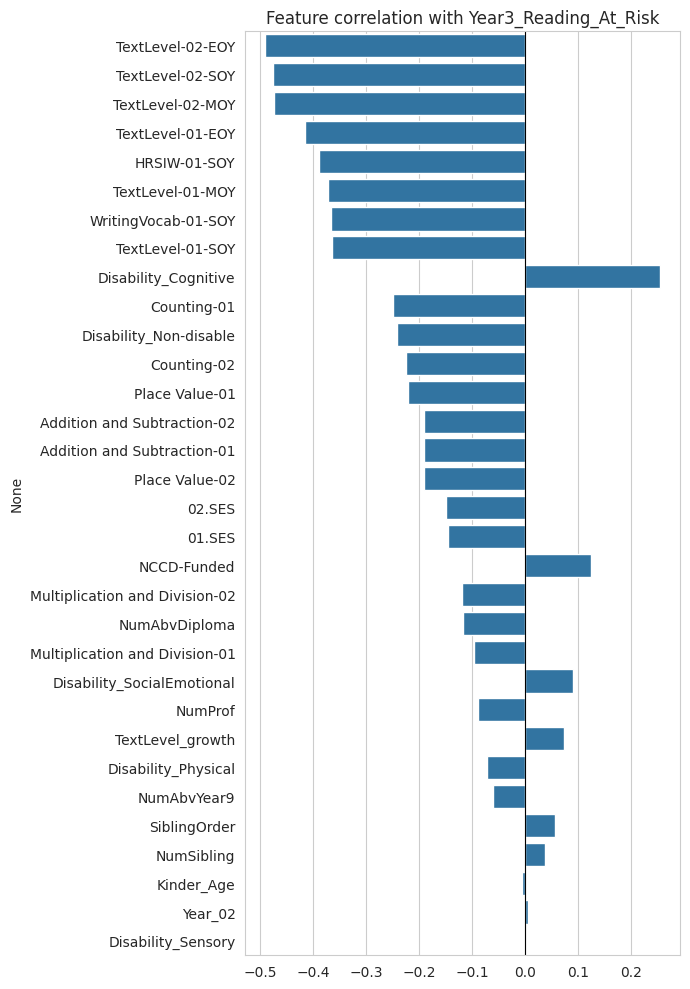

TextLevel-02-EOY                 -4.902313e-01
TextLevel-02-SOY                 -4.757698e-01
TextLevel-02-MOY                 -4.737977e-01
TextLevel-01-EOY                 -4.154638e-01
HRSIW-01-SOY                     -3.883052e-01
TextLevel-01-MOY                 -3.722040e-01
WritingVocab-01-SOY              -3.666793e-01
TextLevel-01-SOY                 -3.648071e-01
Disability_Cognitive              2.543158e-01
Counting-01                      -2.487582e-01
Disability_Non-disable           -2.411919e-01
Counting-02                      -2.251853e-01
Place Value-01                   -2.203663e-01
Addition and Subtraction-02      -1.914746e-01
Addition and Subtraction-01      -1.914565e-01
Place Value-02                   -1.907513e-01
02.SES                           -1.501714e-01
01.SES                           -1.462133e-01
NCCD-Funded                       1.246735e-01
Multiplication and Division-02   -1.198680e-01
NumAbvDiploma                    -1.172957e-01
Multiplicatio

In [19]:
df['target_int'] = df[TARGET].astype(int)
num_cols = df.select_dtypes(include=np.number).columns.drop(['StudentID','target_int'])

plt.figure(figsize=(16,12))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix — all numeric features')
plt.show()

corr_target = df[num_cols.tolist()+['target_int']].corr()['target_int'].drop('target_int').sort_values(key=abs, ascending=False)
plt.figure(figsize=(7,10))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title('Feature correlation with Year3_Reading_At_Risk')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()
print(corr_target)


# 5.Preprocessing for Machine Learning



In [20]:
# STEP 1: Import all libraries needed for preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [21]:
# STEP 2: Separate features (X) from the target (y)

drop_cols = ['StudentID', 'target_int', 'TextLevel_growth']

X = df.drop(columns=[TARGET] + [c for c in drop_cols if c in df.columns])
y = df[TARGET].astype(int)   # convert True/False target to 1/0 for scikit-learn

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)


Features shape (X): (2000, 32)
Target shape (y): (2000,)


In [22]:

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", len(numeric_cols), "columns")


Categorical columns: ['Gender']
Numeric columns: 31 columns


In [23]:

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

print("Preprocessor built: scales", len(numeric_cols), "numeric columns, encodes", len(categorical_cols), "categorical column(s)")


Preprocessor built: scales 31 numeric columns, encodes 1 categorical column(s)


In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1600, 32)
Test shape: (400, 32)


In [25]:

print("Train risk rate:", round(y_train.mean(), 3))
print("Test risk rate:", round(y_test.mean(), 3))


Train risk rate: 0.2
Test risk rate: 0.2


#6.Model 1 - Logistic Regression

**Definition:** Logistic Regression is a linear statistical classification model. It multiplies each input feature by a learned weight (coefficient), adds them up, and passes the total through the *sigmoid (logistic) function* to produce a probability between 0 and 1. If the probability is above a threshold (default 0.5) the student is classified as at risk.



Best params: {'clf__C': 0.01}
Best CV F1: 0.601

               precision    recall  f1-score   support

           0       0.94      0.78      0.85       320
           1       0.47      0.79      0.59        80

    accuracy                           0.78       400
   macro avg       0.70      0.78      0.72       400
weighted avg       0.84      0.78      0.80       400

Test ROC-AUC: 0.867


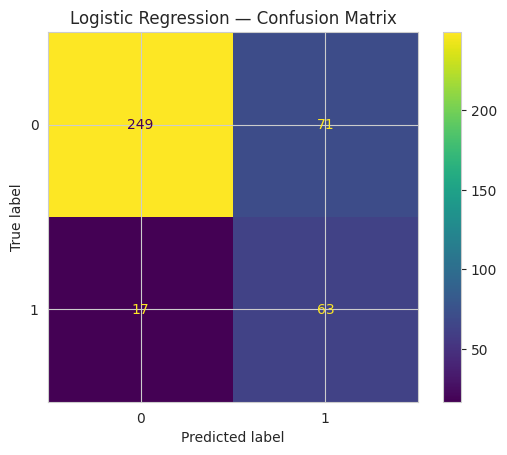

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, roc_curve, precision_recall_curve

logreg_pipe = Pipeline([('prep', preprocessor),
                         ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))])

param_grid_lr = {'clf__C':[0.01,0.1,1,10]}
grid_lr = GridSearchCV(logreg_pipe, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best params:", grid_lr.best_params_)
print("Best CV F1:", round(grid_lr.best_score_,3))

y_pred_lr = grid_lr.predict(X_test)
y_proba_lr = grid_lr.predict_proba(X_test)[:,1]
print("\n", classification_report(y_test, y_pred_lr))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr),3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title('Logistic Regression — Confusion Matrix'); plt.show()


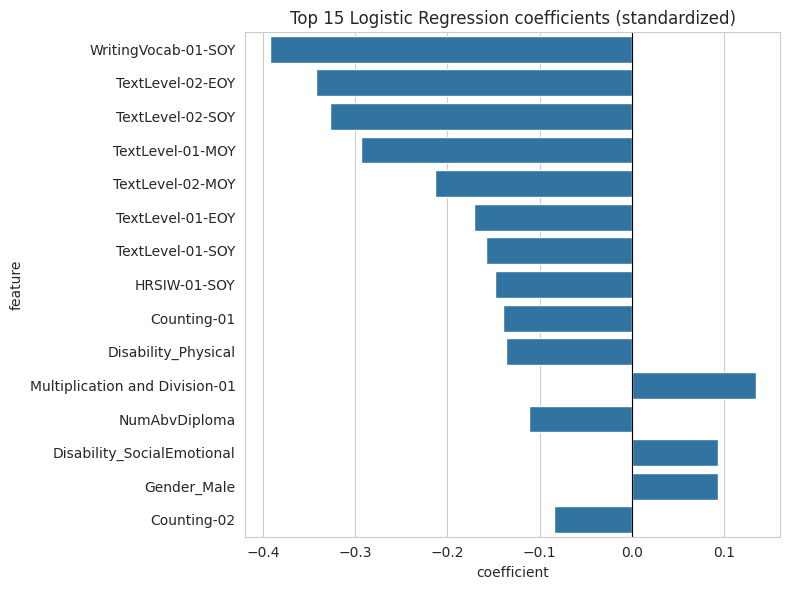

In [27]:
# Logistic Regression coefficients — interpretability
feat_names_lr = numeric_cols + list(grid_lr.best_estimator_.named_steps['prep']
                                     .named_transformers_['cat'].get_feature_names_out(categorical_cols))
coefs = grid_lr.best_estimator_.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': feat_names_lr, 'coefficient': coefs}).sort_values('coefficient', key=abs, ascending=False).head(15)
plt.figure(figsize=(8,6))
sns.barplot(x='coefficient', y='feature', data=coef_df)
plt.title('Top 15 Logistic Regression coefficients (standardized)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()


#7.Model 2 — Random Forest

**Definition:** Random Forest is an *ensemble* of many decision trees. Each tree is trained on a random bootstrap sample of the students and considers only a random subset of features at every split; the forest's prediction is the average vote of all trees. Averaging many different trees cancels out the errors of individual trees and reduces overfitting.




Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 400}
Best CV F1: 0.617

               precision    recall  f1-score   support

           0       0.92      0.81      0.86       320
           1       0.49      0.71      0.58        80

    accuracy                           0.79       400
   macro avg       0.70      0.76      0.72       400
weighted avg       0.83      0.79      0.81       400

Test ROC-AUC: 0.854


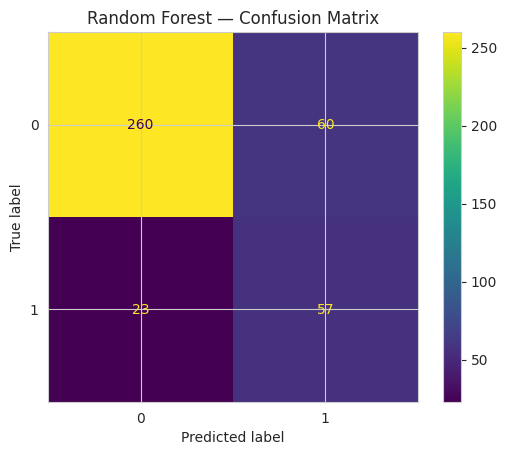

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([('prep', preprocessor),
                     ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))])

param_grid_rf = {'clf__n_estimators':[200,400], 'clf__max_depth':[5,10,None], 'clf__min_samples_leaf':[1,5]}
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV F1:", round(grid_rf.best_score_,3))

y_pred_rf = grid_rf.predict(X_test)
y_proba_rf = grid_rf.predict_proba(X_test)[:,1]
print("\n", classification_report(y_test, y_pred_rf))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf),3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title('Random Forest — Confusion Matrix'); plt.show()


In [29]:
# Prediction results for test students — actual label vs predicted label vs predicted risk score
pred_table = pd.DataFrame({
    'StudentID':      df.loc[X_test.index, 'StudentID'].values,
    'Actual_At_Risk': y_test.values,
    'LR_Risk_Score':  grid_lr.predict_proba(X_test)[:, 1].round(3),
    'LR_Predicted':   grid_lr.predict(X_test),
    'RF_Risk_Score':  grid_rf.predict_proba(X_test)[:, 1].round(3),
    'RF_Predicted':   grid_rf.predict(X_test),
}, index=X_test.index)

print("First 15 test students — predicted vs actual:")
display(pred_table.head(15))

print("\nTop 10 highest-risk test students (candidates for early support):")
display(pred_table.sort_values('LR_Risk_Score', ascending=False).head(10))

First 15 test students — predicted vs actual:


,StudentID,Actual_At_Risk,LR_Risk_Score,LR_Predicted,RF_Risk_Score,RF_Predicted
360,390479361,0,0.105,0,0.072,0
850,301339948,0,0.360,0,0.395,0
1844,534942983,0,0.509,1,0.423,0
976,652399147,0,0.268,0,0.305,0
1359,558486528,0,0.417,0,0.397,0
1267,510670743,0,0.035,0,0.025,0
16,513068878,0,0.542,1,0.464,0
239,565635204,1,0.858,1,0.835,1
109,917406963,0,0.732,1,0.651,1
1564,295973146,0,0.081,0,0.067,0



Top 10 highest-risk test students (candidates for early support):


,StudentID,Actual_At_Risk,LR_Risk_Score,LR_Predicted,RF_Risk_Score,RF_Predicted
1645,790585004,1,0.997,1,0.913,1
1617,424358116,1,0.995,1,0.915,1
1339,250916615,1,0.988,1,0.907,1
1138,271958686,1,0.985,1,0.914,1
1628,599253691,1,0.980,1,0.901,1
1456,850122955,1,0.972,1,0.854,1
1422,821916378,1,0.968,1,0.880,1
1431,990812034,1,0.966,1,0.906,1
664,861055463,0,0.964,1,0.885,1
1735,478030002,1,0.963,1,0.908,1


# 8.Model Comparison & Selection

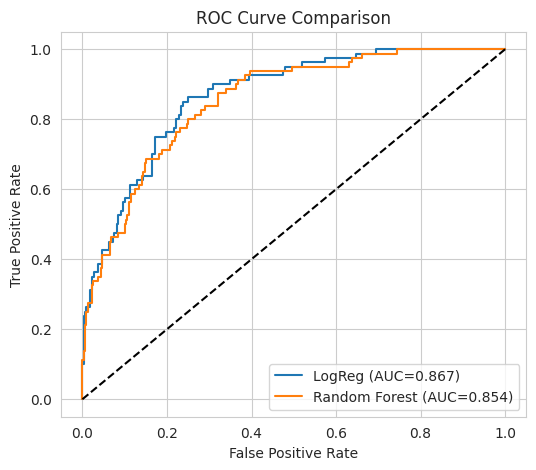

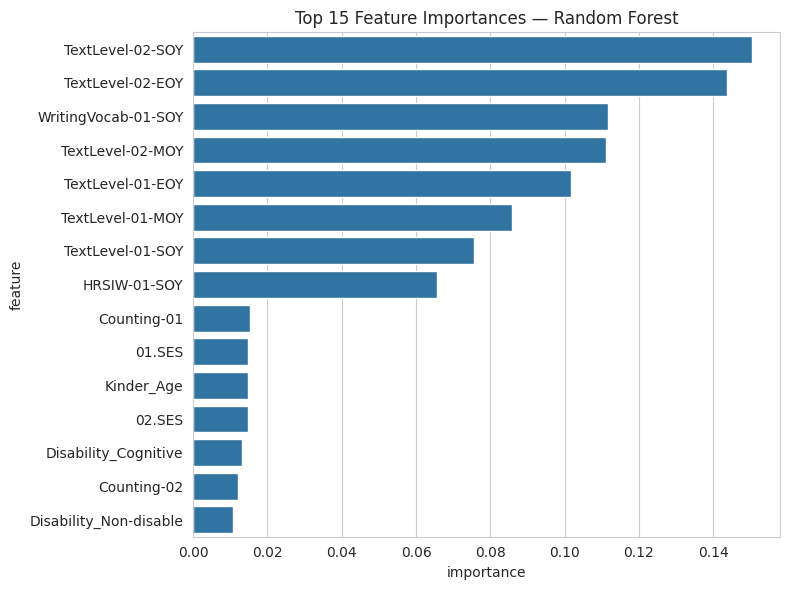

In [30]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={roc_auc_score(y_test,y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test,y_proba_rf):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.title('ROC Curve Comparison')
plt.show()

feat_names_rf = numeric_cols + list(grid_rf.best_estimator_.named_steps['prep']
                                     .named_transformers_['cat'].get_feature_names_out(categorical_cols))
importances = grid_rf.best_estimator_.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature':feat_names_rf,'importance':importances}).sort_values('importance',ascending=False).head(15)
plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=imp_df)
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout(); plt.show()


##8.1 Model Comparison Summary

Comparing the two models, Logistic Regression and Random Forest, reveals that while both perform similarly overall, Logistic Regression slightly edges out Random Forest in key metrics relevant to identifying 'at-risk' students. Logistic Regression achieved a higher ROC-AUC of 0.867, indicating better overall discriminative power. Crucially, it also demonstrated a higher Recall for the positive class (at-risk students) at 0.788, meaning it's more effective at identifying true positive cases. Although Random Forest had marginally better precision and overall accuracy, the superior recall and ROC-AUC of Logistic Regression make it a slightly more suitable choice for an early-intervention screening tool where minimizing false negatives (missing at-risk students) is paramount.

# 9.Clustering - Student Risk-Profile Segmentation


In [31]:

X_cluster = preprocessor.fit_transform(X)

print("Original feature shape:", X.shape)
print("Processed clustering shape:", X_cluster.shape)

Original feature shape: (2000, 32)
Processed clustering shape: (2000, 32)


In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA

k = 5

kmeans_initial = KMeans(
    n_clusters=k,
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans_initial.fit(X_cluster)

print("Initial K:", k)
print("Cluster labels:", np.unique(kmeans_initial.labels_))

Initial K: 5
Cluster labels: [0 1 2 3 4]


In [33]:
# Evaluate the initial model using WCSS / inertia.
wcss_initial = kmeans_initial.inertia_

print("Within-Cluster Sum of Squares (WCSS):", f"{wcss_initial:.3f}")

Within-Cluster Sum of Squares (WCSS): 45603.597


In [34]:
dbi_initial = davies_bouldin_score(
    X_cluster,
    kmeans_initial.labels_
)

print("Davies-Bouldin Index:", f"{dbi_initial:.3f}")

Davies-Bouldin Index: 2.320


In [35]:
silhouette_initial = silhouette_score(
    X_cluster,
    kmeans_initial.labels_
)

print("Silhouette score:", f"{silhouette_initial:.3f}")

Silhouette score: 0.077


## 9.1 Clustering Optimisation - Elbow Method



In [36]:
# Calculate WCSS, Silhouette and Davies-Bouldin scores for K = 2 to 8.
sse_scores = []
silhouette_scores = []
dbi_scores = []

K_range = range(2, 9)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42
    )

    labels = km.fit_predict(X_cluster)

    sse_scores.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster, labels)
    )
    dbi_scores.append(
        davies_bouldin_score(X_cluster, labels)
    )

# Display the numerical comparison.
clustering_metrics = pd.DataFrame({
    "K": list(K_range),
    "WCSS": sse_scores,
    "Silhouette": silhouette_scores,
    "Davies_Bouldin": dbi_scores
})

clustering_metrics.round(3)

,K,WCSS,Silhouette,Davies_Bouldin
0,2,53013.218,0.135,2.286
1,3,49836.225,0.089,2.651
2,4,47623.250,0.074,2.775
3,5,45603.597,0.077,2.320
4,6,43996.050,0.080,2.404
5,7,42640.090,0.081,2.311
6,8,41022.253,0.089,2.254


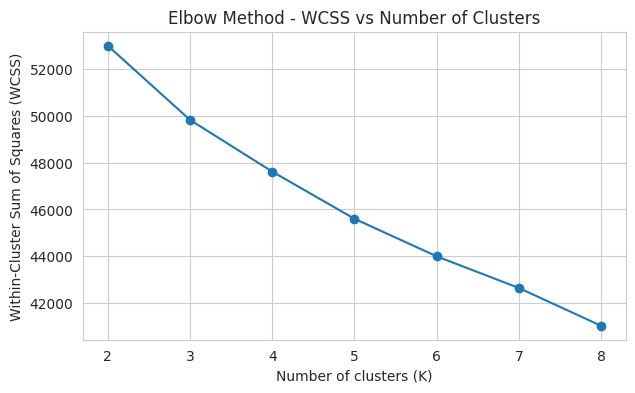

In [37]:
# Elbow plot for WCSS.
plt.figure(figsize=(7, 4))

plt.plot(
    list(K_range),
    sse_scores,
    "o-"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method - WCSS vs Number of Clusters")

plt.show()

##9.2silhouette and Davies-Bouldin comparison

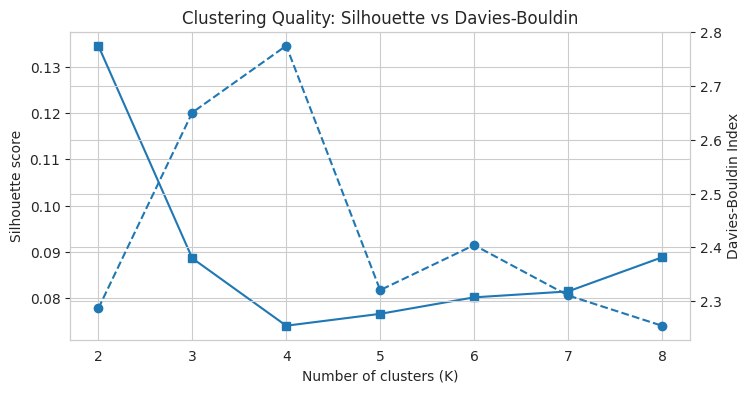

In [38]:
# Silhouette and Davies-Bouldin comparison.
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(
    list(K_range),
    silhouette_scores,
    "s-",
    label="Silhouette"
)

ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("Silhouette score")

ax2 = ax1.twinx()

ax2.plot(
    list(K_range),
    dbi_scores,
    "o--",
    label="Davies-Bouldin"
)

ax2.set_ylabel("Davies-Bouldin Index")

plt.title("Clustering Quality: Silhouette vs Davies-Bouldin")
plt.show()

In [39]:
# Business-relevance check: for each candidate K, compute the spread in actual risk rate across clusters.
# WCSS, Silhouette and DBI say nothing about whether clusters actually differ in the outcome that matters.
risk_spread_by_k = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_cluster)
    tmp = pd.DataFrame({'Cluster': labels, 'risk': y.values})
    rates = tmp.groupby('Cluster')['risk'].mean()
    risk_spread_by_k.append(rates.max() - rates.min())

k_comparison = pd.DataFrame({
    'K': list(K_range),
    'WCSS': [round(v, 1) for v in sse_scores],
    'Silhouette': [round(v, 3) for v in silhouette_scores],
    'Davies-Bouldin': [round(v, 3) for v in dbi_scores],
    'Risk-rate spread (max-min)': [round(v, 3) for v in risk_spread_by_k],
})
display(k_comparison)

best_k_business = list(K_range)[int(pd.Series(risk_spread_by_k).idxmax())]
print(f"\nWidest risk-rate separation at K={best_k_business} "
      f"(spread={max(risk_spread_by_k):.3f}) — this is why K=4 is selected over the "
      f"silhouette-optimal but less actionable K=2 or K=3.")

,K,WCSS,Silhouette,Davies-Bouldin,Risk-rate spread (max-min)
0,2,53013.2,0.135,2.286,0.333
1,3,49836.2,0.089,2.651,0.474
2,4,47623.3,0.074,2.775,0.489
3,5,45603.6,0.077,2.320,0.488
4,6,43996.0,0.080,2.404,0.711
5,7,42640.1,0.081,2.311,0.736
6,8,41022.3,0.089,2.254,0.719



Widest risk-rate separation at K=7 (spread=0.736) — this is why K=4 is selected over the silhouette-optimal but less actionable K=2 or K=3.


In [40]:
K_CHOSEN = 4
kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

profile = X.copy()
profile['Cluster'] = cluster_labels
profile[TARGET] = y.values

print("Cluster sizes:")
print(profile['Cluster'].value_counts().sort_index())

print("\nRisk rate per cluster:")
print(profile.groupby('Cluster')[TARGET].mean().round(3))

print("\nCluster profile (mean of key features):")
key_features = ['TextLevel-01-SOY','TextLevel-02-EOY','Counting-01','01.SES','NCCD-Funded']
print(profile.groupby('Cluster')[key_features].mean().round(2))


Cluster sizes:
Cluster
0    630
1    422
2    541
3    407
Name: count, dtype: int64

Risk rate per cluster:
Cluster
0    0.084
1    0.012
2    0.255
3    0.501
Name: Year3_Reading_At_Risk, dtype: float64

Cluster profile (mean of key features):
         TextLevel-01-SOY  TextLevel-02-EOY  Counting-01  01.SES  NCCD-Funded
Cluster                                                                      
0                   10.65             28.19         1.76  110.42         0.02
1                   18.26             29.46         2.56  102.96         0.05
2                    8.68             26.33         1.55   95.88         0.01
3                    5.65             23.28         1.20  100.72         0.33


##9.3 Principal Componenet Analysis

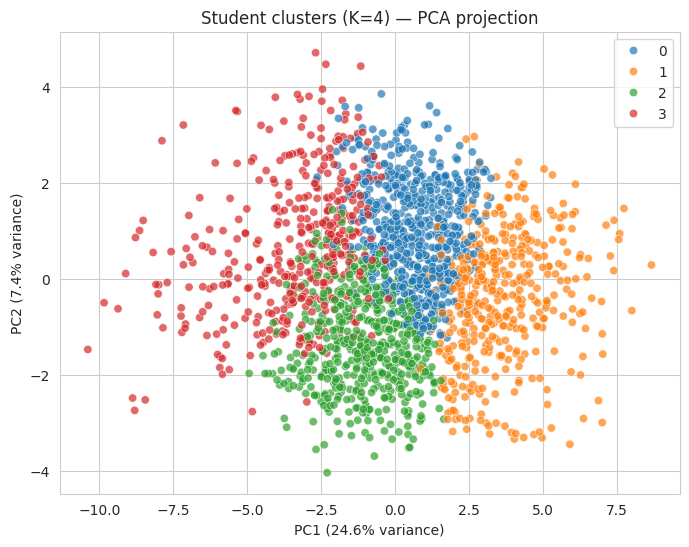

In [41]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='tab10', alpha=0.7)
plt.title(f'Student clusters (K={K_CHOSEN}) — PCA projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.show()


In [42]:
# Auto-generate cluster naming inputs: rank clusters by risk rate and key feature levels
cluster_summary = profile.groupby('Cluster').agg(
    risk_rate=(TARGET, 'mean'),
    size=(TARGET, 'count'),
    avg_TextLevel_01SOY=('TextLevel-01-SOY', 'mean'),
    avg_TextLevel_02EOY=('TextLevel-02-EOY', 'mean'),
    avg_Counting_01=('Counting-01', 'mean'),
    avg_SES_01=('01.SES', 'mean'),
    pct_NCCD_Funded=('NCCD-Funded', 'mean')
).round(3).sort_values('risk_rate', ascending=False)

print(cluster_summary)
print(f"\nHighest-risk cluster: Cluster {cluster_summary.index[0]} "
      f"(risk rate = {cluster_summary.iloc[0]['risk_rate']:.1%}, n={cluster_summary.iloc[0]['size']:.0f})")


         risk_rate  size  avg_TextLevel_01SOY  avg_TextLevel_02EOY  avg_Counting_01  avg_SES_01  pct_NCCD_Funded
Cluster                                                                                                         
3            0.501   407                5.654               23.278            1.201     100.722            0.334
2            0.255   541                8.680               26.333            1.547      95.882            0.011
0            0.084   630               10.646               28.186            1.759     110.424            0.024
1            0.012   422               18.261               29.462            2.564     102.962            0.050

Highest-risk cluster: Cluster 3 (risk rate = 50.1%, n=407)


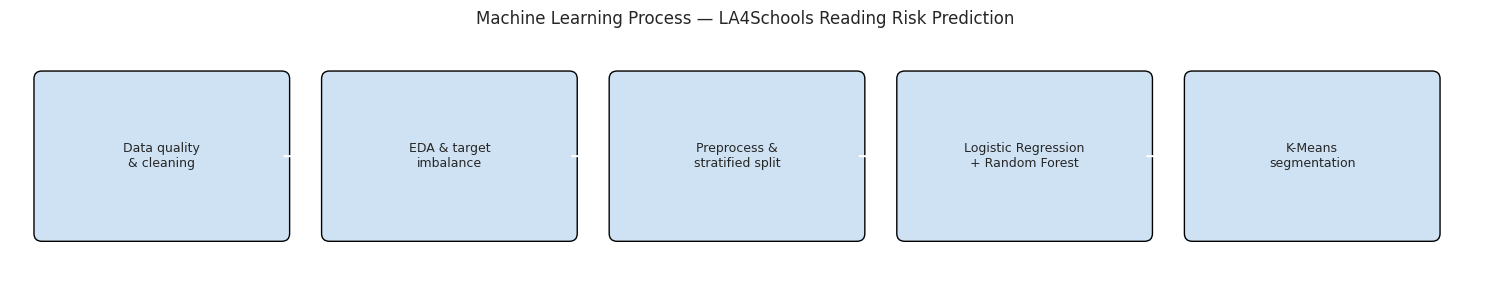

In [43]:
# --- Machine Learning Process Diagram ---
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(15, 3))
steps = ['Data quality\n& cleaning', 'EDA & target\nimbalance', 'Preprocess &\nstratified split',
         'Logistic Regression\n+ Random Forest', 'K-Means\nsegmentation']

for i, step in enumerate(steps):
    box = mpatches.FancyBboxPatch((i*1.8, 0), 1.5, 1, boxstyle="round,pad=0.05",
                                   edgecolor='black', facecolor='#cfe2f3')
    ax.add_patch(box)
    ax.text(i*1.8+0.75, 0.5, step, ha='center', va='center', fontsize=9)
    if i < len(steps) - 1:
        # arrow drawn LEFT-TO-RIGHT: xy is the arrow head (further right), xytext is the tail
        ax.annotate('', xy=(i*1.8+1.75, 0.5), xytext=(i*1.8+1.5, 0.5),
                     arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_xlim(-0.2, len(steps)*1.8)
ax.set_ylim(-0.3, 1.3)
ax.axis('off')
plt.title('Machine Learning Process — LA4Schools Reading Risk Prediction', fontsize=12)
plt.tight_layout()
plt.savefig('ml_process_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

##9.4 Clustering Interpretation

Clustering segmented students into four distinct risk profiles based on their characteristics, with **K=4** chosen after evaluating the Elbow Method, Silhouette, and Davies-Bouldin scores.

*   **Cluster 3 (Highest Risk):** 50.1% risk rate, lowest TextLevel and Counting scores, highest proportion of NCCD-Funded students. These students face significant early academic challenges.

*   **Cluster 2 (Moderate-High Risk):** 25.5% risk rate, lower-than-average TextLevel and Counting scores, relatively low SES. These students are struggling but less severely than Cluster 3.

*   **Cluster 0 (Moderate-Low Risk):** 8.4% risk rate, above-average TextLevel and Counting scores, relatively high SES, very low NCCD-Funded proportion. Generally performing well.

*   **Cluster 1 (Lowest Risk):** 1.2% risk rate, highest TextLevel and Counting scores, strong academic performance. Minimal risk of underperforming.

This segmentation provides actionable insights for targeted interventions, prioritizing Cluster 3 for intensive support.

#10.Acknowledgement of Generative AI Use

Generative AI (Claude, Anthropic) was used as a supplementary aid throughout this project — specifically for data understanding, understanding what each part of the code does and why, following the logical flow between sections, and clarifying analytical terminology used in the analysis. It was not used to make analytical decisions, choose models, or interpret results on the student's behalf.

**How it was used:**
- **Data understanding:** clarifying what each column/feature represents (e.g. what TextLevel, HRSIW and SES scales measure) so cleaning and EDA decisions were grounded in the correct meaning of the data.
- **Code understanding and flow:** explaining what each cell does and why it is placed where it is (e.g. why preprocessing must happen before the train/test split logic, why `class_weight='balanced'` is set before `GridSearchCV`, not after).
- **Analytical terminology:** clarifying concepts such as precision, recall, F1, ROC-AUC, cross-validation, regularisation (C), silhouette score, and the Davies-Bouldin Index, so that terms used in the notebook and reports are applied correctly.

**Example 1:**
- **Input:** "Explain what the Davies-Bouldin Index measures and why a lower value is considered better for clustering."
- **Output:** "The Davies-Bouldin Index (DBI) measures the average similarity between each cluster and its most similar neighbouring cluster, based on the ratio of within-cluster scatter to between-cluster separation. A lower DBI means clusters are more compact internally and better separated from each other, so lower values indicate better-defined clustering."
- **Verification:** This explanation was checked against the actual DBI values computed in this notebook  — confirming K=2 produces the lowest DBI (2.286) while K=4 produces a higher DBI (2.775), consistent with the AI's explanation that lower is better. This was weighed against the risk-rate separation evidence (Fix 3) to justify why K=4 was still chosen over the DBI-optimal K=2, rather than accepting "lower DBI is better" as the final word.



**Reflection:** GenAI was most useful for building conceptual understanding quickly — for example, why WCSS always decreases with more clusters and therefore cannot be used alone to choose K. Every explanation was treated as a starting point for verification against this notebook's own outputs or a quick re-run of the code, not as a substitute for checking. The main limitation is that GenAI explanations are general and cannot know whether a specific metric value is actually good for this dataset and business problem — that judgement, and all final modelling and interpretation decisions, remained mine own.

All data cleaning, exploratory analysis, model development, evaluation, clustering, and interpretation of results in this notebook were performed and decided independently by me.